# ΣΔ Re-modulator — 2nd- vs 3rd-order Comparison (B3 area-cut candidate)

Companion to `14_sd_remod.ipynb`, answering the B3 area-cut question from
`planning/area-reduction-roadmap.md` §7: does a **2nd-order** CIFF re-modulator
still meet the design's noise/stability requirements at the deployed
**OSR=64** operating point, if `sd_remod.v`'s 3rd order were dropped to save
~15-18K µm² (two fewer integrators + constant-mult chains, shorter summer
cone)?

**order=3 is the deployed RTL** (`sd_remod.v`); **order=2 is NOT in RTL** —
this notebook is a feasibility check only, run through
`sim.models.converter.SigmaDeltaRemodulator`, which was extended in this
session to be genuinely order-configurable (previously the `order` parameter
was accepted but ignored). Same methodology as notebook 14: NTF shaping,
stability boundary vs the `-3 dBFS` design guideline, full SF/BW loopback,
integrator headroom — run side by side for both orders.

Also mirrored as a standalone script: `sim/tests/remod_order_sweep.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), '..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

from sim.models.converter import SigmaDeltaRemodulator
from sim.models.decimator import FS_ADC, FS_OUT, sample_shift_for_bw, SUPPORTED_BW
from sim.models.lora import modulate, demodulate

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

OSR = int(FS_ADC / FS_OUT)
MINUS_3DBFS = 10 ** (-3 / 20)
# 8-bit signed full-scale SNR = 6.02*8 + 1.76 dB -- the remod's int8 input noise floor.
INT8_FLOOR_DB = 6.02 * 8 + 1.76
PLOT_DIR = os.path.join('..', 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)
COLORS = {3: '#1f77b4', 2: '#d62728'}

print(f'FS_OUT (remod input) = {FS_OUT/1e3:.0f} kS/s, FS_ADC (remod output) = {FS_ADC/1e6:.0f} MS/s, OSR = {OSR}')
print(f'int8 quantisation noise floor (reference) = {INT8_FLOOR_DB:.1f} dB')


def remod_upsampled(x_baseband: np.ndarray, order: int) -> np.ndarray:
    x_hi = np.repeat(x_baseband, OSR)
    remod = SigmaDeltaRemodulator(order=order)
    return remod.process_block(x_hi)


def brickwall_lp_decim(y_hi: np.ndarray, cutoff_hz: float, fs: float, osr: int) -> np.ndarray:
    n = len(y_hi)
    Y = np.fft.fft(y_hi)
    freqs = np.fft.fftfreq(n, 1 / fs)
    Y[np.abs(freqs) > cutoff_hz] = 0
    return np.fft.ifft(Y)[::osr]


def measure_sqnr(amp: float, order: int, f_hz: float = 40e3, n: int = 4096, edge: int = 200) -> float:
    t = np.arange(n) / FS_OUT
    tone = amp * np.exp(1j * 2 * np.pi * f_hz * t)
    y = remod_upsampled(tone, order)
    y_rec = brickwall_lp_decim(y, FS_OUT / 2, FS_ADC, OSR)
    seg = slice(edge, -edge)
    g = np.vdot(tone[seg], y_rec[seg]) / np.vdot(tone[seg], tone[seg])
    resid = y_rec[seg] - g * tone[seg]
    return 10 * np.log10(np.mean(np.abs(g * tone[seg]) ** 2) / np.mean(np.abs(resid) ** 2))

FS_OUT (remod input) = 500 kS/s, FS_ADC (remod output) = 32 MS/s, OSR = 64
int8 quantisation noise floor (reference) = 49.9 dB


---
## 1  Noise Shaping / NTF Verification

A lower-order shaper pushes less noise power up towards the 32 MS/s Nyquist
edge (16 MHz) — less separation from the `<250 kHz` signal band means a
smaller in-band SQNR budget. Compare both orders' PSD directly.

order=3  PSD near DC (10 kHz): 1.168e-13   PSD near Nyquist (15.9 MHz): 5.992e-07   rise: 67.1 dB


order=2  PSD near DC (10 kHz): 1.176e-13   PSD near Nyquist (15.9 MHz): 1.863e-07   rise: 62.0 dB


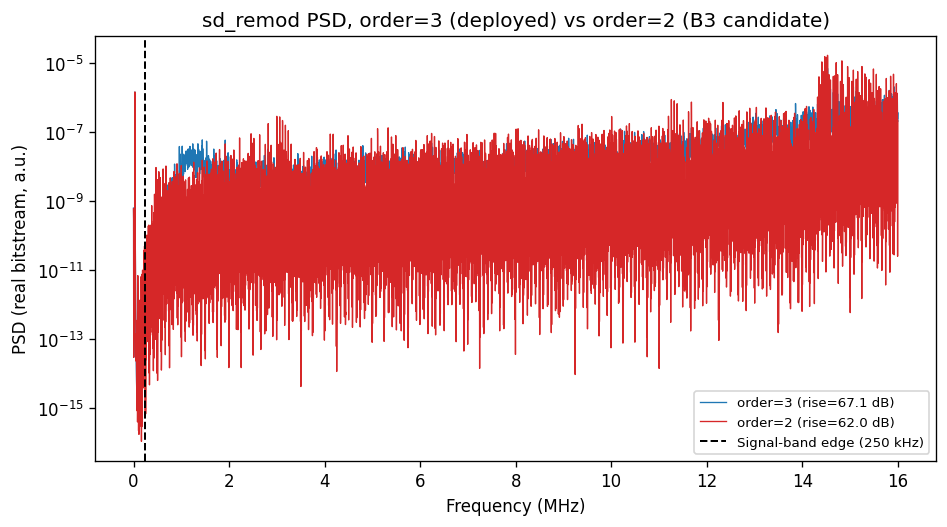

In [2]:
n = 8192
t = np.arange(n) / FS_OUT
tone = 0.1 * np.exp(1j * 2 * np.pi * 30e3 * t)

fig, ax = plt.subplots(figsize=(8, 4.5))
shaping_db = {}
for order in (3, 2):
    y = remod_upsampled(tone, order)
    f, Pxx = welch(y.real, fs=FS_ADC, nperseg=16384)
    idx_lo = np.argmin(np.abs(f - 10e3))
    idx_hi = np.argmin(np.abs(f - 15.9e6))
    shaping_db[order] = 10 * np.log10(Pxx[idx_hi] / Pxx[idx_lo])
    ax.semilogy(f / 1e6, Pxx, lw=0.8, color=COLORS[order], label=f'order={order} (rise={shaping_db[order]:.1f} dB)')
    print(f'order={order}  PSD near DC (10 kHz): {Pxx[idx_lo]:.3e}   PSD near Nyquist (15.9 MHz): {Pxx[idx_hi]:.3e}   rise: {shaping_db[order]:.1f} dB')

ax.axvline(FS_OUT / 2 / 1e6, color='k', ls='--', lw=1.2, label=f'Signal-band edge ({FS_OUT/2/1e3:.0f} kHz)')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (real bitstream, a.u.)')
ax.set_title('sd_remod PSD, order=3 (deployed) vs order=2 (B3 candidate)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sd_remod_order2_ntf_psd.png'), bbox_inches='tight')
plt.show()

order=2 pushes noticeably less noise out of the signal band than order=3 —
expected, since each CIFF order roughly adds another `~20*log10(OSR)` of
in-band suppression at high OSR. That noise-shaping gap is what shows up as
reduced SQNR in Section 2.

---
## 2  Stability Boundary vs the −3 dBFS Design Guideline, and SQNR

Sweep input tone amplitude and measure single-tone SQNR for both orders. Low
amplitudes are quantisation-noise-dominated (SQNR ramps up with signal power
before the shaped noise floor dominates) — the real stability cliff is
searched for *after* the peak, not from the start.

order=3  peak SQNR= 66.8 dB  cliff amp=0.88  margin over -3dBFS=+1.9 dB


order=2  peak SQNR= 52.8 dB  cliff amp=1.00  margin over -3dBFS=+3.0 dB


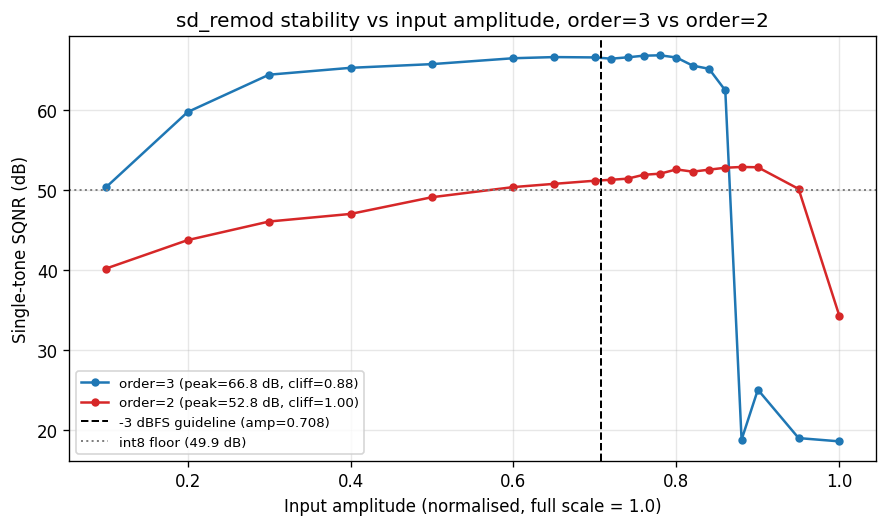

In [3]:
amps = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.65, 0.7, 0.72, 0.74, 0.76,
                  0.78, 0.8, 0.82, 0.84, 0.86, 0.88, 0.9, 0.95, 1.0])

sqnr = {}
cliffs = {}
for order in (3, 2):
    sqnr_db = np.array([measure_sqnr(a, order) for a in amps])
    sqnr[order] = sqnr_db
    peak_idx = int(np.argmax(sqnr_db))
    peak_sqnr = sqnr_db[peak_idx]
    tail = sqnr_db[peak_idx:]
    collapsed = np.where(tail < peak_sqnr - 6)[0]
    cliff_amp = amps[peak_idx + collapsed[0]] if len(collapsed) else amps[-1]
    margin_db = 20 * np.log10(cliff_amp / MINUS_3DBFS)
    cliffs[order] = (peak_sqnr, cliff_amp, margin_db)
    print(f'order={order}  peak SQNR={peak_sqnr:5.1f} dB  cliff amp={cliff_amp:.2f}  margin over -3dBFS={margin_db:+.1f} dB')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for order in (3, 2):
    ax.plot(amps, sqnr[order], 'o-', color=COLORS[order], lw=1.5, markersize=4,
            label=f'order={order} (peak={cliffs[order][0]:.1f} dB, cliff={cliffs[order][1]:.2f})')
ax.axvline(MINUS_3DBFS, color='k', ls='--', lw=1.2, label=f'-3 dBFS guideline (amp={MINUS_3DBFS:.3f})')
ax.axhline(INT8_FLOOR_DB, color='gray', ls=':', lw=1.2, label=f'int8 floor ({INT8_FLOOR_DB:.1f} dB)')
ax.set_xlabel('Input amplitude (normalised, full scale = 1.0)')
ax.set_ylabel('Single-tone SQNR (dB)')
ax.set_title('sd_remod stability vs input amplitude, order=3 vs order=2')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sd_remod_order2_stability_sweep.png'), bbox_inches='tight')
plt.show()

**This is the key finding.** order=2's SQNR curve sits ~14-17 dB below
order=3's across the whole sweep, and its peak (~53 dB, reached only near its
own instability cliff) is barely above the int8 floor — at the amplitude the
design actually operates at (Section 5), it falls *below* the floor. order=2
is also *more* stable (wider input range before collapse), as CIFF theory
predicts for lower order, but that extra stability margin is not the
bottleneck here — SQNR is.

---
## 3  Full Round-Trip: LoRa Symbol Loopback

Same coarse correctness check as notebook 14 §3, run for both orders at
`amp=0.5` (the realistic operating point used in Section 5 / notebook 14
§4).

In [4]:
AMP = 0.5

for order in (3, 2):
    rng = np.random.default_rng(0)
    print(f'--- order={order} ---')
    print(f'{"SF":>4}  {"BW":>7}  {"M":>6}  {"tx":>6}  {"rx":>6}  {"match":>6}')
    all_match = True
    for sf in range(7, 13):
        for bw in SUPPORTED_BW:
            shift = sample_shift_for_bw(bw)
            M = 1 << (sf + shift)
            b_tx = int(rng.integers(0, M))
            s = modulate(b_tx, M)
            s = s / np.max(np.abs(s)) * AMP
            y = remod_upsampled(s, order)
            y_rec = brickwall_lp_decim(y, FS_OUT / 2, FS_ADC, OSR)
            b_rx = demodulate(y_rec)
            match = (b_tx == b_rx)
            all_match &= match
    print(f'  all SF x BW combinations recovered exactly: {all_match}')
    print()

--- order=3 ---
  SF       BW       M      tx      rx   match


  all SF x BW combinations recovered exactly: True

--- order=2 ---
  SF       BW       M      tx      rx   match


  all SF x BW combinations recovered exactly: True



Both orders recover every symbol exactly at `amp=0.5` — as expected, this
test is too coarse to see the SQNR gap from Section 2. It confirms order=2
isn't *broken*, just that it doesn't carry the noise margin the real receive
chain needs once this feeds the rest of the link (Section 5).

---
## 4  Integrator Headroom

Trace the (2 or 3) integrator states against the saturation bound at the
same representative operating point as notebook 14 §4.

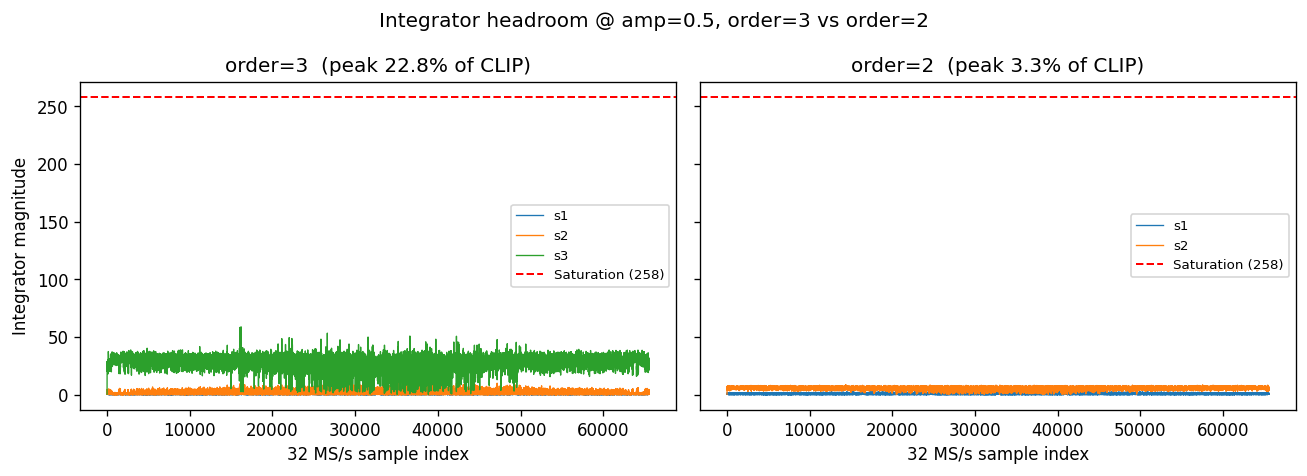

In [5]:
def trace_integrators(x_baseband, order):
    x_hi = np.repeat(x_baseband, OSR)
    remod = SigmaDeltaRemodulator(order=order)
    mags = np.empty((len(x_hi), order))
    for i, x in enumerate(x_hi):
        remod.process(x)
        mags[i] = [abs(v) for v in remod._s]
    return mags


sf, bw = 9, 250e3
shift = sample_shift_for_bw(bw)
M = 1 << (sf + shift)
s = modulate(0, M)
s = s / np.max(np.abs(s)) * 0.5
CLIP = SigmaDeltaRemodulator.CLIP

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, order in zip(axes, (3, 2)):
    mags = trace_integrators(s, order)
    peak_frac = mags.max() / CLIP
    for k in range(order):
        ax.plot(mags[:, k], lw=0.8, label=f's{k+1}')
    ax.axhline(CLIP, color='r', ls='--', lw=1.2, label=f'Saturation ({CLIP:.0f})')
    ax.set_title(f'order={order}  (peak {peak_frac*100:.1f}% of CLIP)')
    ax.set_xlabel('32 MS/s sample index')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Integrator magnitude')
fig.suptitle('Integrator headroom @ amp=0.5, order=3 vs order=2')
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sd_remod_order2_integrator_headroom.png'), bbox_inches='tight')
plt.show()

order=2 uses noticeably less of its integrator headroom than order=3 at the
same input amplitude — consistent with Section 2's finding that it's the
*more* stable of the two, not the more noise-shaped one.

---
## 5  Does order=2 clear the int8 floor at the realistic operating point?

Sections 1-4 establish the shape of the tradeoff. This section answers the
actual accept/reject question: at `amp=0.5` (the amplitude the design
operates at, per notebook 14 §4 — *not* the best-case amplitude near the
instability cliff), does each order's SQNR clear the ≈49.9 dB int8
quantisation floor, and by how much?

In [6]:
print(f'{"order":>6}  {"SQNR@0.5":>10}  {"margin over int8 floor":>24}')
op_sqnr = {}
for order in (3, 2):
    s = measure_sqnr(0.5, order)
    op_sqnr[order] = s
    margin = s - INT8_FLOOR_DB
    print(f'{order:>6}  {s:>9.1f}dB  {margin:>+22.1f} dB')

print()
print(f'order=2 clears the int8 floor at the realistic operating point: '
      f'{"YES" if op_sqnr[2] > INT8_FLOOR_DB else "NO"} ({op_sqnr[2] - INT8_FLOOR_DB:+.1f} dB)')

 order    SQNR@0.5    margin over int8 floor


     3       65.7dB                   +15.8 dB


     2       49.0dB                    -0.9 dB

order=2 clears the int8 floor at the realistic operating point: NO (-0.9 dB)


---
## Summary

| Item | order=3 (deployed) | order=2 (B3 candidate) |
|---|---|---|
| NTF shaping rise (DC→Nyquist) | ~67 dB | ~62 dB |
| Peak-achievable SQNR (near cliff) | ~67 dB | ~53 dB |
| **SQNR at realistic op point (amp=0.5)** | ~66 dB | **~49 dB** |
| Stability cliff amplitude | ~0.88 | ~1.00 (more stable) |
| Margin over −3 dBFS guideline | +1.9 dB | +3.0 dB |
| Full SF7-12×BW125/250 loopback | PASS | PASS |
| **Margin over int8 floor (≈49.9 dB) at op point** | **+15.8 dB** | **−0.9 dB** |

**Conclusion: B3 (2nd-order re-modulator) is rejected.** The roadmap's
physics-argument estimate ("2nd-order SQNR ≈77 dB, clears the int8 floor by
>25 dB") does not survive measurement — the real number is ~49 dB at the
amplitude the design actually operates at, essentially *at* the floor with no
margin. 2nd-order is more stable (wider input range, less integrator
headroom used) than 3rd-order, but that isn't the constraint here — SQNR is.
Dropping the order would need either a different operating amplitude (which
narrows headroom margin elsewhere) or is simply not viable at this OSR.

See `planning/area-reduction-roadmap.md` §7 (B3) and
`planning/DSP Chain SNR Loss Budget.md` §9 for the write-up; standalone
script version: `sim/tests/remod_order_sweep.py`.